In [1]:
import mlflow
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from pgd_optim_pytorch._utils import parallel_coordinates_plot
%matplotlib inline

In [2]:
# Set the tracking URI to the directory containing the mlruns folder
mlflow.set_tracking_uri("../../../mlruns")

# IB

We used pGD to learn the minima of the IB for various values of $\gamma$, for every experiment.

## Load and pre-process the data

In [3]:
# Retrieve all runs from the experiment of interest
experiment = mlflow.get_experiment_by_name("IB tests")
experiment_id = experiment.experiment_id
print(experiment_id)

623000886928194751


In [4]:
try:
    runs_df = pd.read_csv('ib_results.csv')
except FileNotFoundError:
    # Extract df from mlflow directly
    runs_df = mlflow.search_runs(experiment_ids=experiment_id, max_results=100000)
    # Export the DataFrame to a CSV file
    runs_df.to_csv('ib_results.csv', index=False)

print(len(runs_df))
print(runs_df.columns)

18
Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.HTcondX', 'metrics.diff_q', 'metrics.HY',
       'metrics.VI of T and T_', 'metrics.Expected optimal HTcondX',
       'metrics.loss', 'metrics.converged', 'metrics.penalty', 'metrics.HT',
       'metrics.Final IB loss', 'metrics.Expected optimal HYcondT',
       'metrics.HYcondT', 'metrics.Expected optimal HT', 'metrics.HcYdoT',
       'metrics.Expected optimal HcYdoT', 'metrics.Expected optimal IB loss',
       'metrics.diff_loss', 'params.max iter', 'params.bs', 'params.gamma',
       'params.end_lr_factor', 'params.bxi', 'params.beta', 'params.eps',
       'params.lr', 'params.by', 'params.Learned q',
       'params.Expected optimal q', 'params.r_y', 'params.uncertainty_y',
       'tags.mlflow.source.name', 'tags.mlflow.source.git.commit',
       'tags.mlflow.user', 'tags.method', 'tags.mlflow.runName',
       'tags.mlflow.source.type', 'tags.optimizer', 'tags.loss'],
      dtype

In [5]:
# Add duration metric
runs_df['metrics.duration']=(pd.to_datetime(runs_df['end_time'], format='ISO8601') - pd.to_datetime(runs_df['start_time'], format='ISO8601')).dt.total_seconds()

In [6]:
# Only need some columns
runs = runs_df[[
      'metrics.duration',
      'params.uncertainty_y',
      'params.r_y',
      'params.bxi',
      'params.by',
      'params.bs',
      'params.gamma',
      'params.beta',
      'params.lr',
      'metrics.VI of T and T_',
      'metrics.Final IB loss',
      'metrics.HT',
      'metrics.HTcondX',
      'metrics.HY',
      'metrics.HcYdoT',
      'metrics.converged',
      'params.Learned q',
      'tags.optimizer',
      'tags.loss'
]]

In [7]:
# List of columns that should be float
float_columns = ['params.uncertainty_y', 'params.r_y', 'params.bxi', 'params.by', 'params.bs', 'params.gamma', 'params.beta', 'params.lr'] 
runs.loc[:, float_columns] = runs[float_columns].apply(pd.to_numeric, errors='raise')

# Remove prefixes
runs.columns = runs.columns.str.split('.').str[1]

# Add MI, Ic columns
runs.loc[:, ['MI_XT']] = runs['HT'] - runs['HTcondX']
runs.loc[:, ['IcYdoT']] = runs['HY'] - runs['HcYdoT']
runs.head()

,duration,uncertainty_y,r_y,bxi,by,bs,gamma,beta,lr,VI of T and T_,...,HT,HTcondX,HY,HcYdoT,converged,Learned q,optimizer,loss,MI_XT,IcYdoT
0,13.523,NaN,NaN,0.3,0.1,0.5,1.0,inf,1.0,1.143309,...,1.870346,-0.000000,2.014693,1.407550,1.0,"tensor([[[[[1., 1.],\n [1., 0.]],\n\...",pGD,wIB,1.870346e+00,0.607143
1,35.155,NaN,NaN,0.3,0.1,0.5,0.8,4.000000,1.0,0.662451,...,1.420375,0.281619,2.014693,1.400055,0.0,"tensor([[[[[0.0000, 0.0000],\n [0.00...",pGD,wIB,1.138755e+00,0.614638
2,34.448,NaN,NaN,0.3,0.1,0.5,0.6,1.500000,1.0,3.011346,...,1.988463,1.744740,2.014693,2.019120,0.0,"tensor([[[[[0.1500, 0.2400],\n [0.24...",pGD,wIB,2.437230e-01,-0.004426
3,7.908,NaN,NaN,0.3,0.1,0.5,0.4,0.666667,1.0,3.375384,...,1.942425,1.942426,2.014693,2.361816,1.0,"tensor([[[[[0.2000, 0.2000],\n [0.20...",pGD,wIB,-3.576279e-07,-0.347123
4,5.587,NaN,NaN,0.3,0.1,0.5,0.2,0.250000,1.0,3.417461,...,1.984827,1.984827,2.014693,2.361816,1.0,"tensor([[[[[0.2200, 0.2200],\n [0.22...",pGD,wIB,-2.384186e-07,-0.347123


In [8]:
#min_losses = runs.groupby(['gamma', 'uncertainty_y'], as_index=False)['Final CIB loss'].min()
#
## Merge the original DataFrame with the minimum losses DataFrame
#df_merged = pd.merge(runs, min_losses, on=['gamma', 'uncertainty_y', 'Final CIB loss'])
#
## Drop duplicates to keep only one row per gamma value
#best_runs = df_merged.drop_duplicates(subset=['gamma', 'uncertainty_y'])
##best_runs

## Odd and Even

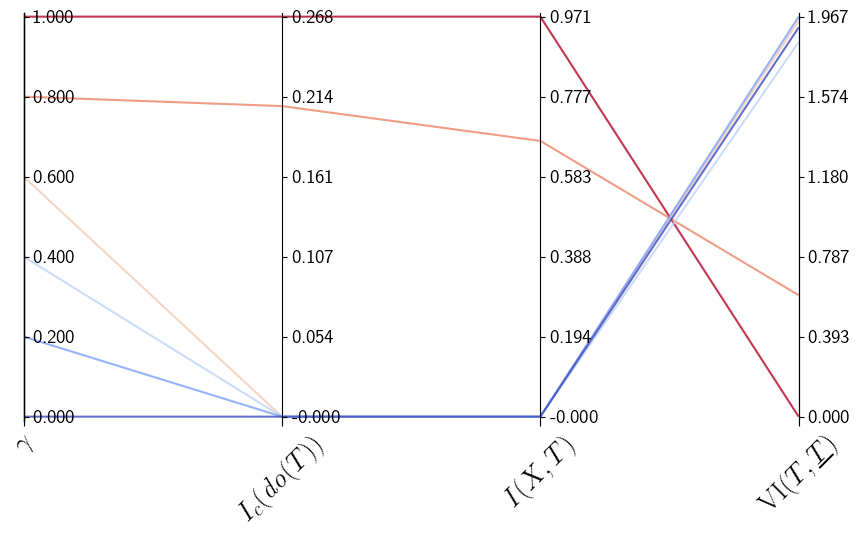

In [9]:
conditions = (~runs['uncertainty_y'].isna() )
filtered_runs = runs[conditions]

columns_to_plot = ['gamma', 'IcYdoT', 'MI_XT', 'VI of T and T_']

final_labels = {
    'gamma': r'$\gamma$',
    'IcYdoT': r'$I_{c}(\mathit{do}(T))$',
    'MI_XT': r'$I(X, T)$',
    'VI of T and T_': r'$\mathrm{VI}(T, \underline{T})$'
}
parallel_coordinates_plot(filtered_runs, columns_to_plot, label_renaming=final_labels, savepath="IB_parallel_plot_odd_and_even.png")

## Confounded Addition

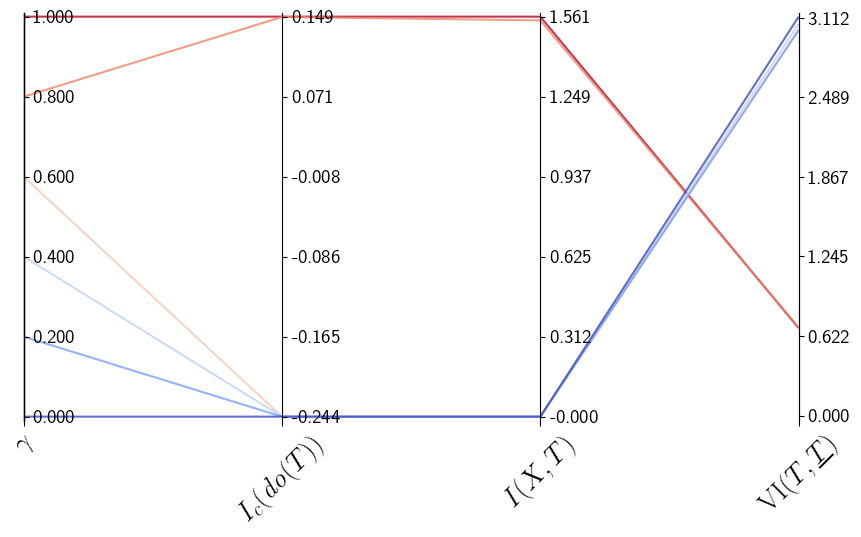

In [10]:
conditions = (~runs['r_y'].isna() )
filtered_runs = runs[conditions]

columns_to_plot = ['gamma', 'IcYdoT', 'MI_XT', 'VI of T and T_']

final_labels = {
    'gamma': r'$\gamma$',
    'IcYdoT': r'$I_{c}(\mathit{do}(T))$',
    'MI_XT': r'$I(X, T)$',
    'VI of T and T_': r'$\mathrm{VI}(T, \underline{T})$'
}
parallel_coordinates_plot(filtered_runs, columns_to_plot, label_renaming=final_labels, savepath="IB_parallel_plot_addition.png", start_at_zero=['VI of T and T_'])

## Genetic Mutations

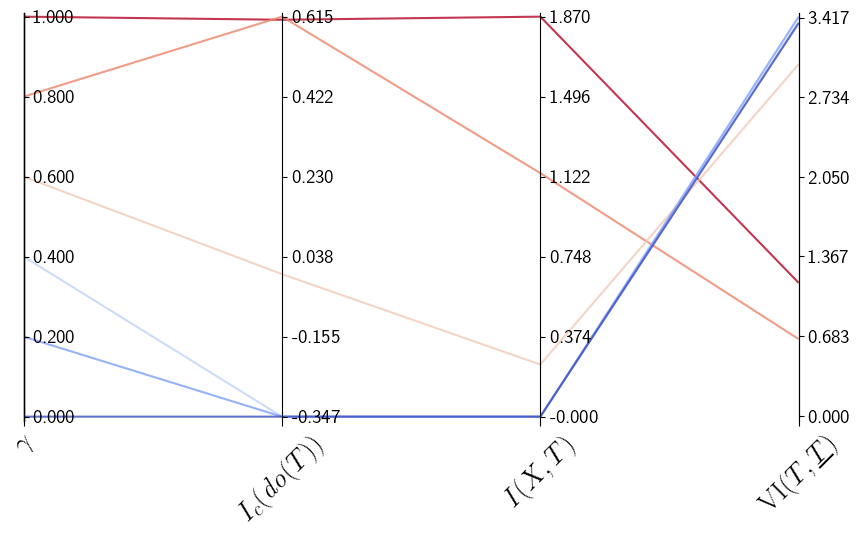

In [11]:
conditions = (~runs['by'].isna() )
filtered_runs = runs[conditions]

columns_to_plot = ['gamma', 'IcYdoT', 'MI_XT', 'VI of T and T_']

final_labels = {
    'gamma': r'$\gamma$',
    'IcYdoT': r'$I_{c}(\mathit{do}(T))$',
    'MI_XT': r'$I(X, T)$',
    'VI of T and T_': r'$\mathrm{VI}(T, \underline{T})$'
}
parallel_coordinates_plot(filtered_runs, columns_to_plot, label_renaming=final_labels, savepath="IB_parallel_plot_mutations.png", start_at_zero=['VI of T and T_'])